# Indeed Hiring Analysis: AI Skill Demand vs Total Job Market

## Background and Data Journey

We initially started with only one dataset from Indeed's 
Hiring Lab: the share of job postings that mention AI as 
a required skill (`indeedAI_clean.csv`). This dataset 
covers 9 countries from 2019 to 2026 on a daily basis.

**Note on data representation:**
The total job posting index used here is sourced from 
Indeed's Hiring Lab and represents job postings on 
Indeed's platform only. While Indeed is one of the 
largest job platforms globally, it does not capture 
the entire job market. The trends observed here should 
be interpreted as indicative of broader labor market 
directions rather than absolute measures of total 
hiring activity.

**Limitation with AI share data alone:**
When we looked at the trend, we noticed something 
unexpected. AI hiring share actually dipped right after 
ChatGPT launched in November 2022, before surging upward 
from 2023 onwards. This was counterintuitive. Our initial 
hypothesis was a denominator effect: if total job postings 
surged after ChatGPT, the AI share (a percentage) could 
drop even if the absolute number of AI-related postings 
stayed the same or grew. But we could not confirm or deny 
this with just the AI share data.

**Why we added total job postings data:**
We sourced a second Indeed dataset, the total job posting 
index (`TotalIndeed_clean.csv`). This is an index where 
February 2020 = 100, so values above 100 mean more 
postings than the baseline. By combining both datasets, 
we can directly compare AI hiring share against 
job posting volume on the same platform.

**What this analysis covers:**
Our dataset spans 2020 to 2026, a period that captures 
five distinct macro episodes:

1. **COVID-19 crash (early 2020):** lockdowns triggered 
   an immediate collapse in job postings across all 
   9 countries

2. **Post-COVID hiring boom (2020-2022):** as lockdowns 
   eased, companies aggressively rehired, driving 
   Indeed job postings to around 66% above the 
   Feb 2020 baseline by mid-2022

3. **ChatGPT launch and tech hiring freeze 
   (late 2022 - mid 2023):** rising interest rates, 
   post-pandemic correction, and mass tech layoffs 
   caused a sharp reversal; ChatGPT launched right 
   in the middle of this freeze

4. **The AI hiring boom and the great divergence 
   (2024-2026):** AI skill requirements surged even 
   as job postings on Indeed continued declining, 
   suggesting AI competency became a structural 
   expectation rather than a specialist requirement

5. **Country-level AI adoption divergence:** markets 
   like the US, Canada, Ireland, Germany, and Australia 
   embedded AI requirements faster and more broadly, 
   while Continental European markets like France, 
   Italy, and the Netherlands lagged significantly

By bringing the two datasets together, this notebook 
traces how each of these episodes affected AI hiring 
specifically, and what the post-2023 divergence tells 
us about how hiring expectations have structurally changed.

### Datasets:
- `indeedAI_clean.csv`: daily AI share of job postings 
  (%) across 9 countries, 2019-2026
- `TotalIndeed_clean.csv`: daily total job posting index 
  (Feb 2020 = 100) across 9 countries, 2020-2026

### Structure:
1. Setup
2. Load and merge data
3. Dual axis analysis: AI share vs total job index
4. Correlation analysis: how do the two series relate?
5. Normalized comparison: recovery timing and 
   the great divergence
6. Country comparison: pre vs post ChatGPT
7. Key findings summary
8. Export daily data for combined Reddit + Indeed analysis

## 1. Setup

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11
})

CHATGPT_LAUNCH = pd.Timestamp('2022-11-30')

COUNTRIES = [
    'Australia', 'Canada', 'France', 'Germany', 'Ireland',
    'Italy', 'Netherlands', 'United Kingdom', 'United States'
]

COUNTRY_COLORS = {
    'United States':  '#E07B39',
    'Ireland':        '#C44E52',
    'Canada':         '#4878CF',
    'United Kingdom': '#6ACC65',
    'Australia':      '#D65F5F',
    'Germany':        '#B47CC7',
    'France':         '#C4AD66',
    'Italy':          '#77BEDB',
    'Netherlands':    '#92C6FF',
}

# key events used across multiple charts
EVENTS = [
    ('COVID\ncrash',        pd.Timestamp('2020-03-01'), 0.97),
    ('Post-COVID\nboom',    pd.Timestamp('2020-09-01'), 0.75),
    ('Tech hiring\nfreeze', pd.Timestamp('2022-11-01'), 0.97),
    ('ChatGPT\nlaunched',   pd.Timestamp('2022-11-30'), 0.75),
    ('AI hiring\nboom',     pd.Timestamp('2023-07-01'), 0.97),
]

ERA_LABELS = [
    ('COVID\ncrash',     pd.Timestamp('2020-03-15')),
    ('Post-COVID\nboom', pd.Timestamp('2021-04-01')),
    ('Tech\nfreeze',     pd.Timestamp('2023-01-01')),
    ('AI hiring\nboom',  pd.Timestamp('2024-06-01')),
]

print('Setup complete.')

Setup complete.


## 2. Load and Merge Data

Both datasets are daily, but daily data is noisy for a 
6-year trend analysis. We aggregate to monthly means 
before merging. This smooths out day-to-day fluctuations 
while preserving the underlying trends across the five 
macro episodes we want to study.

One important note: the total job posting index starts 
in February 2020, which is set as the baseline month 
where all countries = 100. The AI share data goes back 
to 2019. Our merged dataset therefore covers February 
2020 onwards. February 2020 serves as our reference 
point and everything after is measured relative to it. 
This overlap period captures all five episodes, starting 
just one month before the COVID crash hit in March 2020.

In [38]:
# load AI share data
ai_df = pd.read_csv('indeedAI_clean.csv')
ai_df['date'] = pd.to_datetime(ai_df['date'])
ai_df['month'] = ai_df['date'].dt.to_period('M')

# load total job index data
total_df = pd.read_csv('TotalIndeed_clean.csv')
total_df['date'] = pd.to_datetime(total_df['date'])
total_df['month'] = total_df['date'].dt.to_period('M')

# aggregate both to monthly
ai_monthly = (
    ai_df.groupby(['country', 'country_code', 'month'])
    ['ai_share_pct'].mean().reset_index()
)
total_monthly = (
    total_df.groupby(['country', 'country_code', 'month'])
    ['job_index'].mean().reset_index()
)

# inner join keeps only the overlap period (Feb 2020 onwards)
combined = ai_monthly.merge(
    total_monthly[['country', 'month', 'job_index']],
    on=['country', 'month'],
    how='inner'
)
combined['month_dt'] = combined['month'].dt.to_timestamp()

print(f'AI data:    {len(ai_monthly):,} rows')
print(f'Total data: {len(total_monthly):,} rows')
print(f'Combined:   {len(combined):,} rows')
print(f'Date range: {combined["month_dt"].min().date()} to {combined["month_dt"].max().date()}')
print()
print(combined.head())

AI data:    765 rows
Total data: 666 rows
Combined:   648 rows
Date range: 2020-02-01 to 2026-01-01

     country country_code    month  ai_share_pct   job_index   month_dt
0  Australia           AU  2020-02      2.440690  100.287931 2020-02-01
1  Australia           AU  2020-03      2.770000   93.470000 2020-03-01
2  Australia           AU  2020-04      2.818000   51.543000 2020-04-01
3  Australia           AU  2020-05      2.705806   47.938710 2020-05-01
4  Australia           AU  2020-06      2.279333   58.024333 2020-06-01


## 3. Dual Axis Analysis: AI Share vs Total Job Index

We plot both series on the same time axis with separate 
y-axes since they are in different units. Key macro events 
are annotated directly on the chart so each movement in 
the data can be connected to its real-world cause.

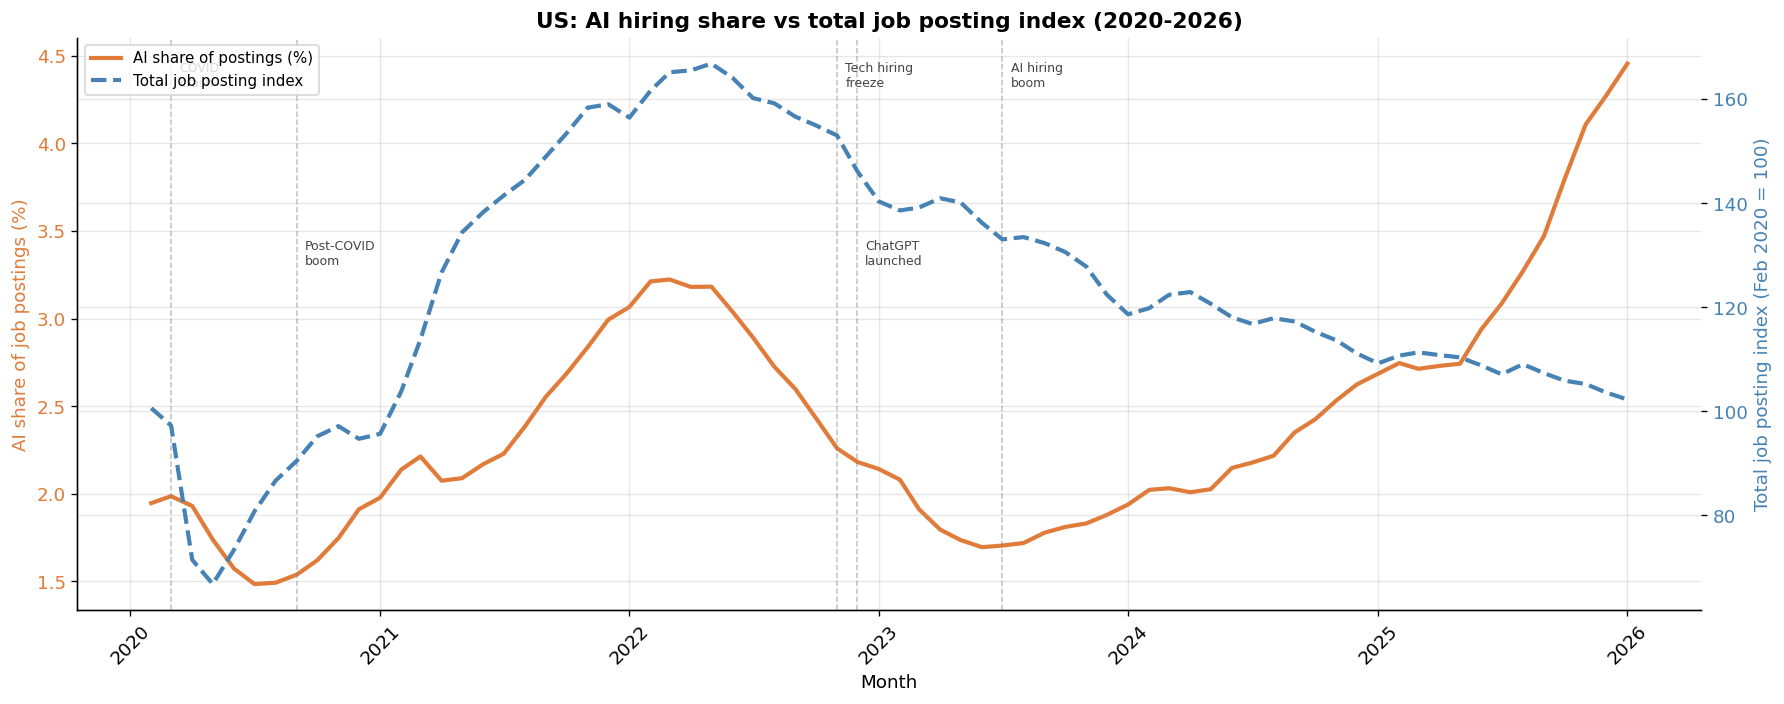

In [39]:
# US dual axis with event annotations

us = combined[combined['country'] == 'United States'].sort_values('month_dt')

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(us['month_dt'], us['ai_share_pct'],
         color='#E07B39', linewidth=2.5, label='AI share of postings (%)')
ax1.set_ylabel('AI share of job postings (%)', color='#E07B39', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#E07B39')

ax2 = ax1.twinx()
ax2.plot(us['month_dt'], us['job_index'],
         color='steelblue', linewidth=2.5,
         linestyle='--', label='Total job posting index')
ax2.set_ylabel('Total job posting index (Feb 2020 = 100)',
               color='steelblue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.spines['top'].set_visible(False)

for label, date, height in EVENTS:
    ax1.axvline(date, color='gray', linewidth=0.9,
                linestyle='--', alpha=0.5)
    ax1.text(date + pd.DateOffset(days=12),
             ax1.get_ylim()[1] * height,
             label, fontsize=7.5, color='#444444',
             va='top', ha='left')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9)

ax1.set_title('US: AI hiring share vs total job posting index (2020-2026)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Month')
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('01_us_dual_axis.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: US dual axis**

**COVID crash (early 2020):**
Indeed job postings dropped sharply, falling 34% below 
the Feb 2020 baseline at the worst point. AI hiring share 
also dipped but held up better, as tech companies remained 
relatively resilient during the remote work transition.

**Post-COVID hiring boom (2020-2022):**
As lockdowns eased, job postings on Indeed surged to 65.8% 
above the Feb 2020 baseline by mid-2022. AI hiring share 
climbed alongside it. Both lines rising together shows AI 
hiring was simply riding the wave of general market growth 
during this period.

**ChatGPT launch and tech hiring freeze (late 2022 - mid 2023):**
Rising interest rates, post-pandemic correction, and 
over-hiring all converged simultaneously. Meta cut 11,000 
jobs in November 2022, Amazon 18,000 in January 2023, 
Google 12,000 in January 2023. ChatGPT launched right 
into this environment, which is why AI hiring share dipped 
immediately after launch rather than spiking. The freeze 
hit AI roles significantly harder than general roles, 
as shown in the normalized analysis.

##### Sources:
- Meta 11,000 layoffs (November 2022): [SEC Filing](https://www.sec.gov/Archives/edgar/data/0001326801/000132680122000116/nov092022exhibit991.htm) | [CNBC](https://www.cnbc.com/2023/01/18/tech-layoffs-microsoft-amazon-meta-others-have-cut-more-than-60000.html)
- Amazon 18,000 layoffs (January 2023): [CNBC](https://www.cnbc.com/2023/01/18/tech-layoffs-microsoft-amazon-meta-others-have-cut-more-than-60000.html)
- Google 12,000 layoffs (January 2023): [CNBC](https://www.cnbc.com/2023/01/18/tech-layoffs-microsoft-amazon-meta-others-have-cut-more-than-60000.html) | [Crunchbase](https://news.crunchbase.com/startups/tech-layoffs/)

**AI hiring boom: companies hire less but demand more (2024-2026):**
Once the freeze ended the two lines moved in completely 
opposite directions. Indeed job postings continued 
declining from their freeze lows, never recovering 
to 2022 levels. AI hiring share did not just recover, 
it surged far above any previous level. Companies are 
not posting more jobs overall but they are increasingly 
requiring AI competency from whoever they do hire.

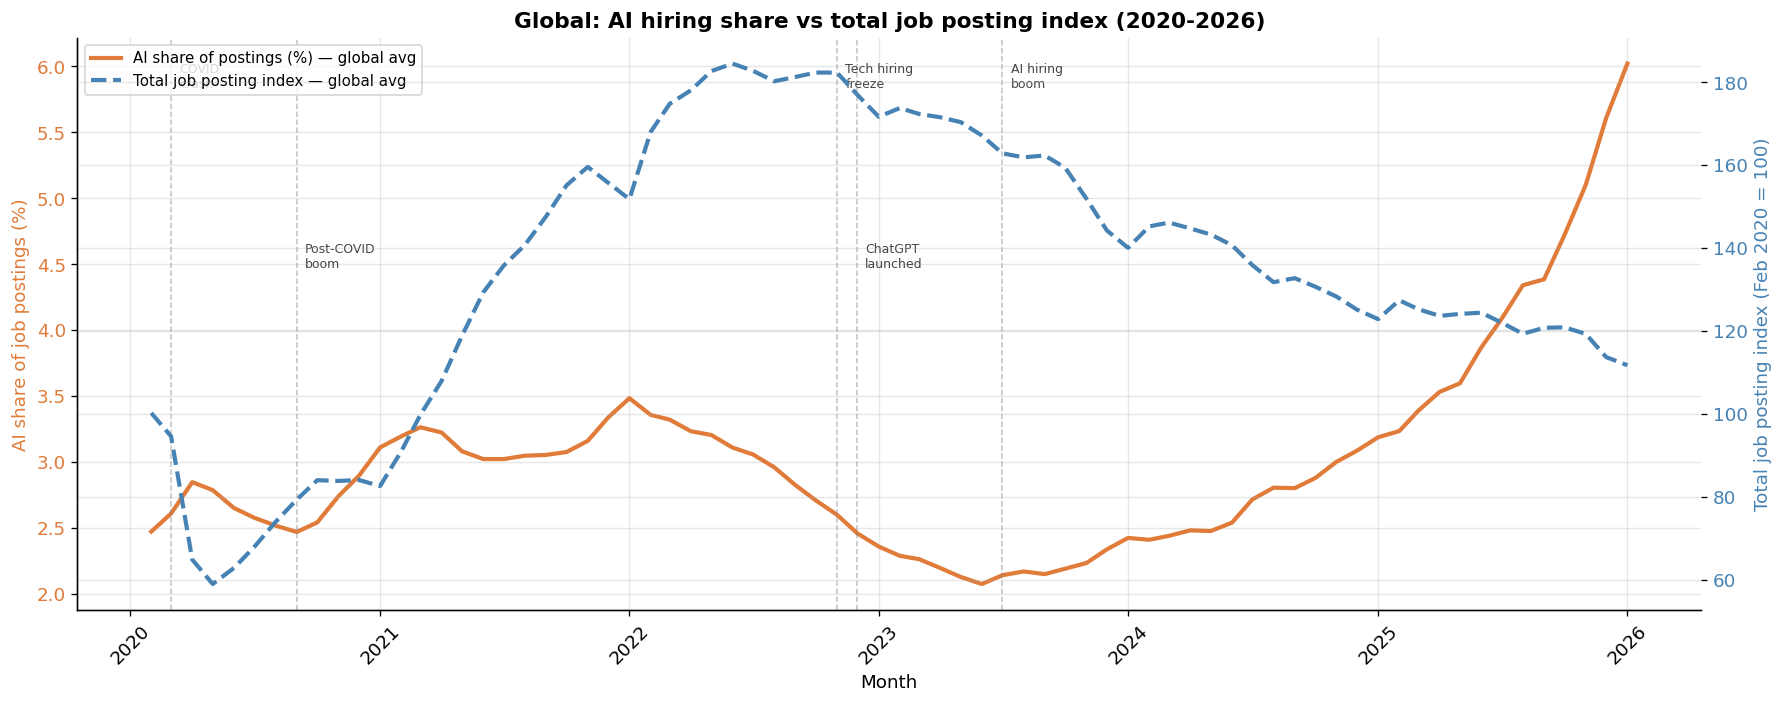

In [40]:
# global average dual axis with event annotations

global_monthly = (
    combined.groupby('month_dt')
    .agg(
        ai_share_pct = ('ai_share_pct', 'mean'),
        job_index    = ('job_index',    'mean')
    )
    .reset_index()
    .sort_values('month_dt')
)

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(global_monthly['month_dt'], global_monthly['ai_share_pct'],
         color='#E07B39', linewidth=2.5, label='AI share of postings (%) — global avg')
ax1.set_ylabel('AI share of job postings (%)', color='#E07B39', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#E07B39')

ax2 = ax1.twinx()
ax2.plot(global_monthly['month_dt'], global_monthly['job_index'],
         color='steelblue', linewidth=2.5,
         linestyle='--', label='Total job posting index — global avg')
ax2.set_ylabel('Total job posting index (Feb 2020 = 100)',
               color='steelblue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.spines['top'].set_visible(False)

for label, date, height in EVENTS:
    ax1.axvline(date, color='gray', linewidth=0.9,
                linestyle='--', alpha=0.5)
    ax1.text(date + pd.DateOffset(days=12),
             ax1.get_ylim()[1] * height,
             label, fontsize=7.5, color='#444444',
             va='top', ha='left')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9)

ax1.set_title('Global: AI hiring share vs total job posting index (2020-2026)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Month')
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('02_global_dual_axis.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: Global dual axis**

The global picture mirrors the US pattern but with 
one difference: Indeed job postings globally have 
held up better than the US alone, staying above 
the Feb 2020 baseline through to January 2026 
(index at 111.5 vs US at 101.6). This is largely 
because Continental European markets like Italy, 
France, and the Netherlands did not experience 
the same severity of tech layoffs and their 
post-COVID hiring recovery was stronger.

However the global job index has also been 
declining steadily since mid-2024, falling from 
140.4 in June 2024 to 111.5 by January 2026. 
The direction is the same as the US, just 
less severe.

Meanwhile global AI hiring share surged to 243.5 
by January 2026, actually higher than the US at 
228.8. Companies across all 9 countries are 
embedding AI requirements into job postings 
regardless of whether their overall posting 
volume is growing or contracting. The AI boom 
is not a US-only story.

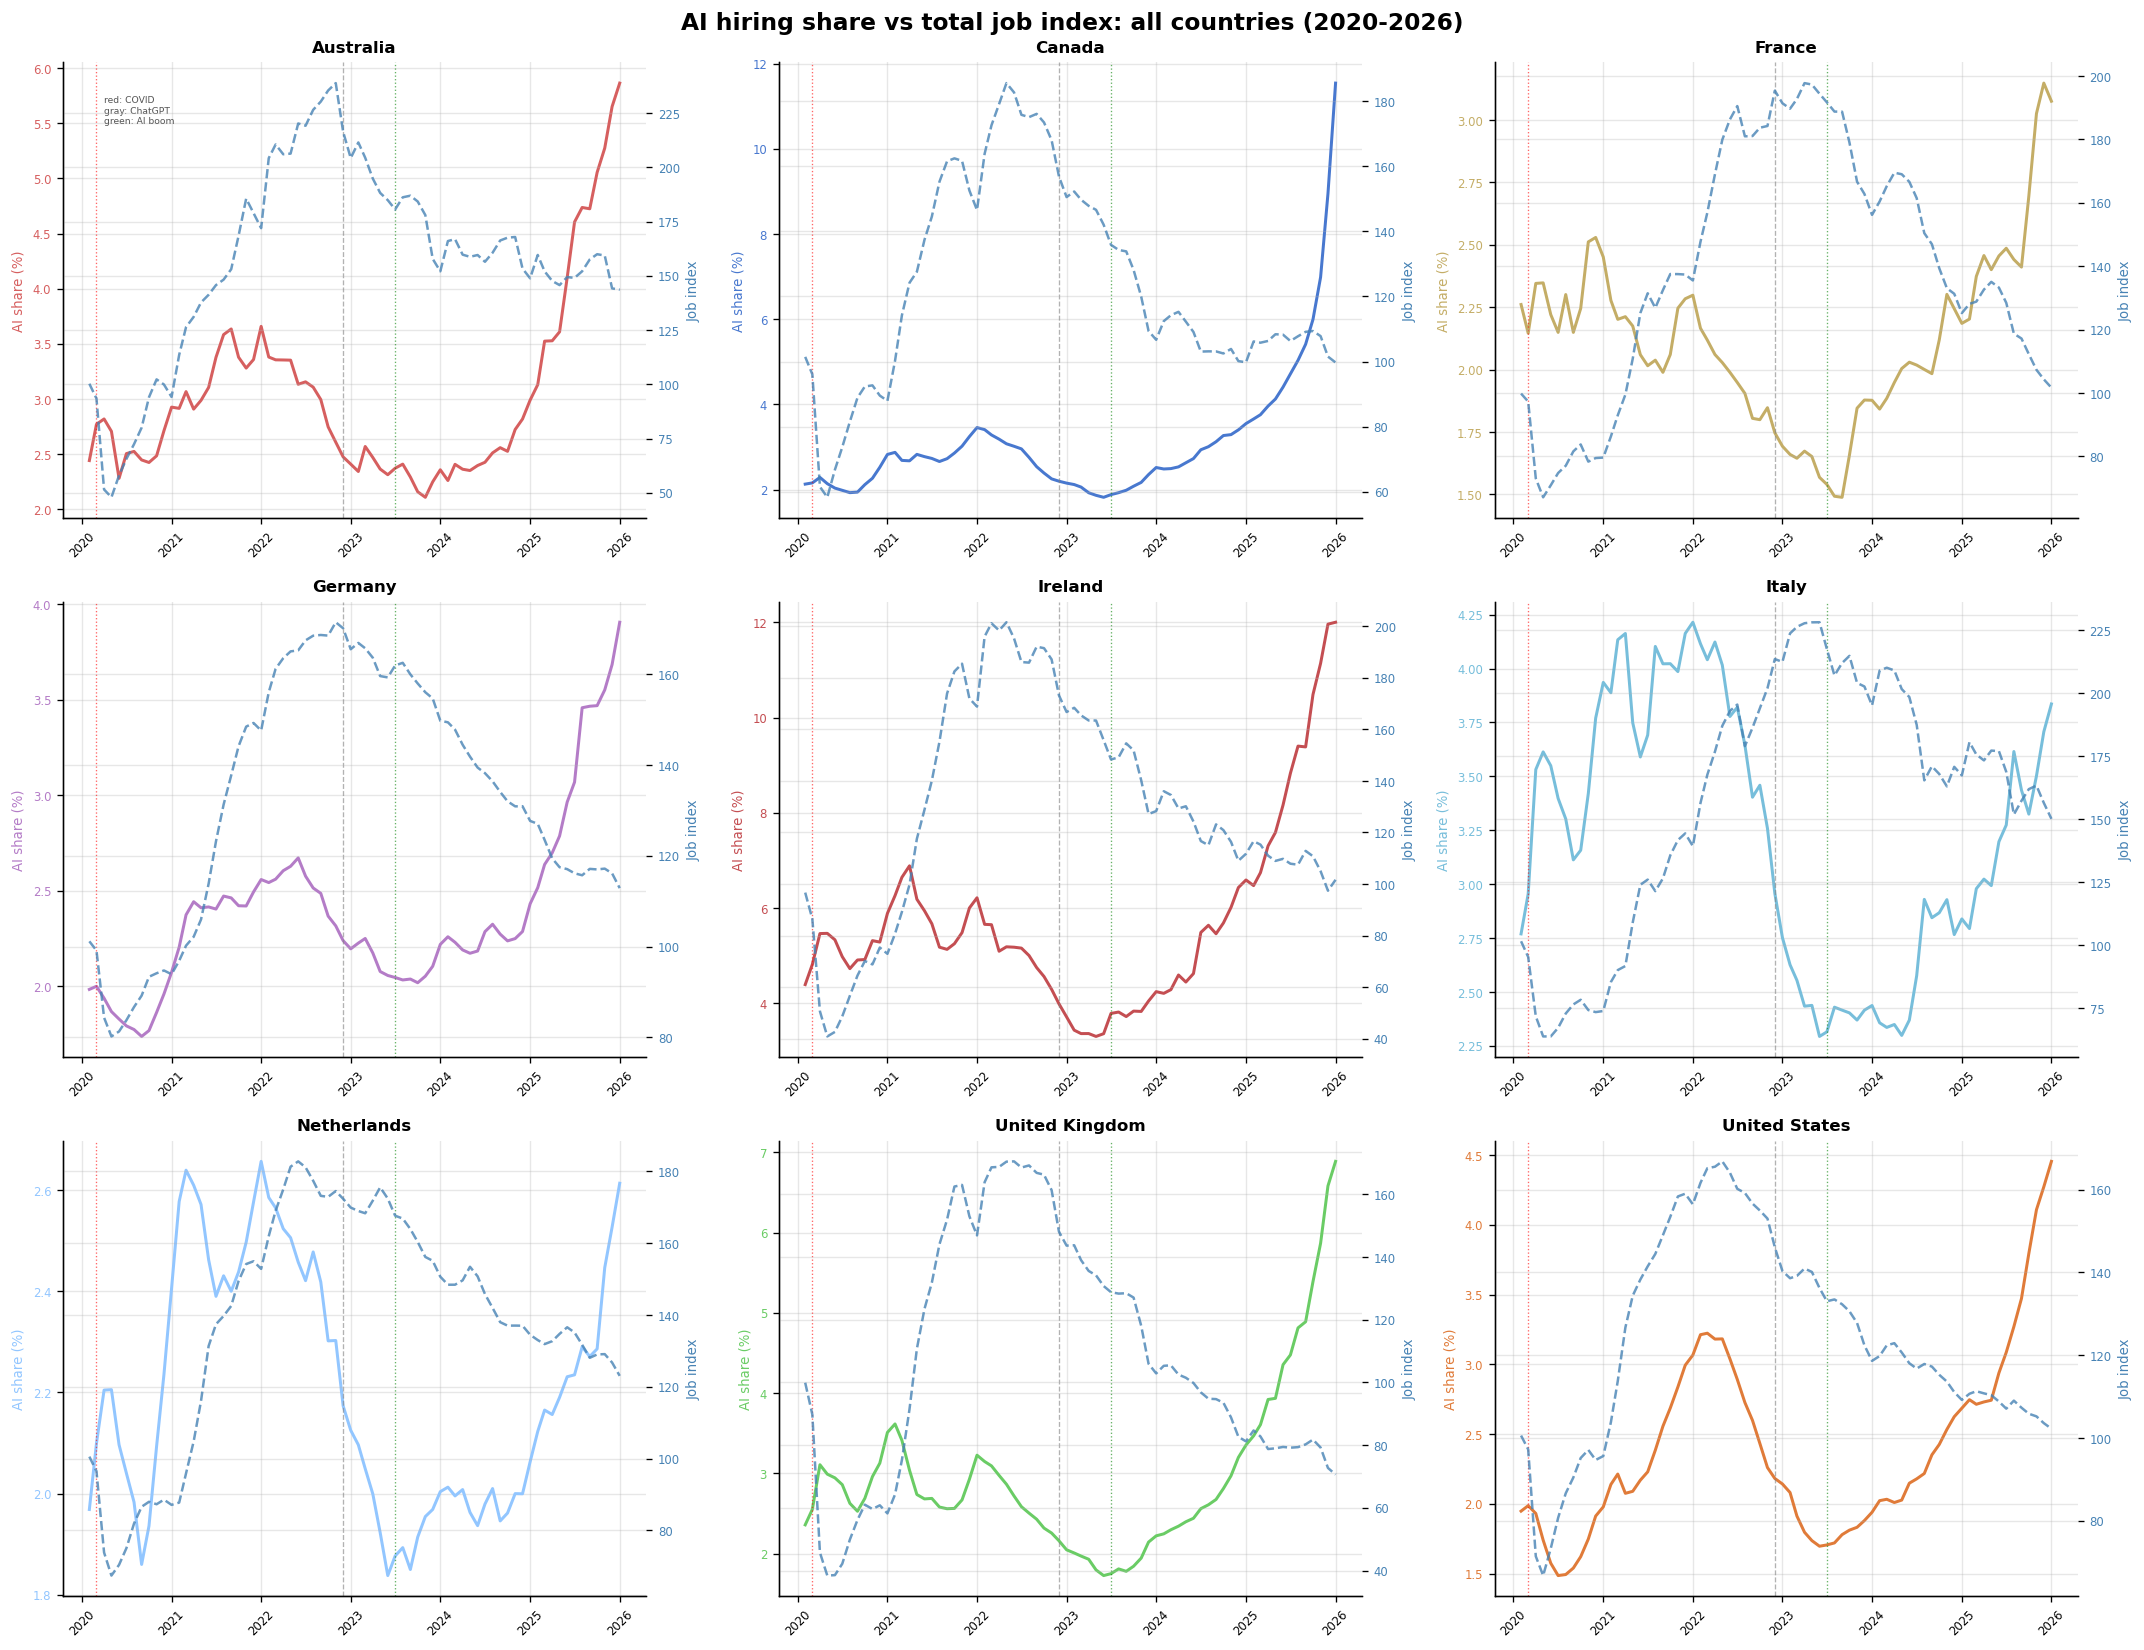

In [41]:
# country level dual-axis charts

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('AI hiring share vs total job index: all countries (2020-2026)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, country in enumerate(COUNTRIES):
    cdata = combined[combined['country'] == country].sort_values('month_dt')
    ax1 = axes[i]

    ax1.plot(cdata['month_dt'], cdata['ai_share_pct'],
             color=COUNTRY_COLORS[country], linewidth=1.8, label='AI share')
    ax1.set_ylabel('AI share (%)', color=COUNTRY_COLORS[country], fontsize=8)
    ax1.tick_params(axis='y', labelcolor=COUNTRY_COLORS[country], labelsize=7)

    ax2 = ax1.twinx()
    ax2.plot(cdata['month_dt'], cdata['job_index'],
             color='steelblue', linewidth=1.5,
             linestyle='--', label='Job index', alpha=0.8)
    ax2.set_ylabel('Job index', color='steelblue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=7)
    ax2.spines['top'].set_visible(False)

    # mark COVID, ChatGPT launch, AI boom start
    ax1.axvline(pd.Timestamp('2020-03-01'), color='red',
                linewidth=0.8, linestyle=':', alpha=0.6)
    ax1.axvline(CHATGPT_LAUNCH, color='gray',
                linewidth=0.8, linestyle='--', alpha=0.6)
    ax1.axvline(pd.Timestamp('2023-07-01'), color='green',
                linewidth=0.8, linestyle=':', alpha=0.6)

    if i == 0:
        ax1.text(pd.Timestamp('2020-04-01'),
                 ax1.get_ylim()[1] * 0.95,
                 'red: COVID\ngray: ChatGPT\ngreen: AI boom',
                 fontsize=5.5, color='#555555', va='top')

    ax1.set_title(country, fontsize=10, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('03_all_countries_dual_axis.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: Country grid**

**Ireland and Canada:**
Both show AI hiring share spikes far above any other 
country. Ireland averages 5.42% and Canada recorded 
the highest single month in the dataset at 12.6%. 
These markets have concentrated tech sectors and are 
the most sensitive to AI hiring trends.

**US and UK:**
Both follow the same narrative: post-COVID boom, 
freeze dip, then AI surge. The US AI share climbs 
higher, reflecting deeper concentration of AI-first 
companies.

**France and Italy:**
Strong job posting recovery post-COVID but AI hiring 
share lines are comparatively flat. General hiring 
boomed but AI requirements did not follow. Classic 
denominator effect.

**Germany, Netherlands, Australia:**
Sit in the middle with modest but consistent AI share 
growth. Gradual adoption path, likely where the US 
and UK were two or three years ago.

## 4. Correlation Analysis: How Do the Two Series Relate?

We compute the Pearson correlation between Indeed's total 
job posting index and AI hiring share for each country 
across the full overlap period.

A negative correlation means the denominator effect is 
real: when job postings grew, AI share shrank as a 
percentage. A positive correlation means AI hiring 
share grew alongside overall posting volume.

In [42]:
# correlation per country

correlations = []
for country in COUNTRIES:
    cdata = combined[combined['country'] == country].dropna()
    r = cdata['job_index'].corr(cdata['ai_share_pct'])
    correlations.append({'country': country, 'correlation': r})

corr_df = pd.DataFrame(correlations).sort_values('correlation')

print('Pearson correlation: job_index vs ai_share_pct')
print(corr_df.to_string(index=False))
print()
print('Negative = denominator effect (total jobs up, AI share down)')
print('Positive = AI adoption effect (AI share grows with overall market)')

Pearson correlation: job_index vs ai_share_pct
       country  correlation
        France    -0.734855
         Italy    -0.589713
United Kingdom    -0.427969
       Ireland    -0.314720
        Canada    -0.138838
   Netherlands     0.009639
     Australia     0.017553
       Germany     0.052913
 United States     0.229881

Negative = denominator effect (total jobs up, AI share down)
Positive = AI adoption effect (AI share grows with overall market)


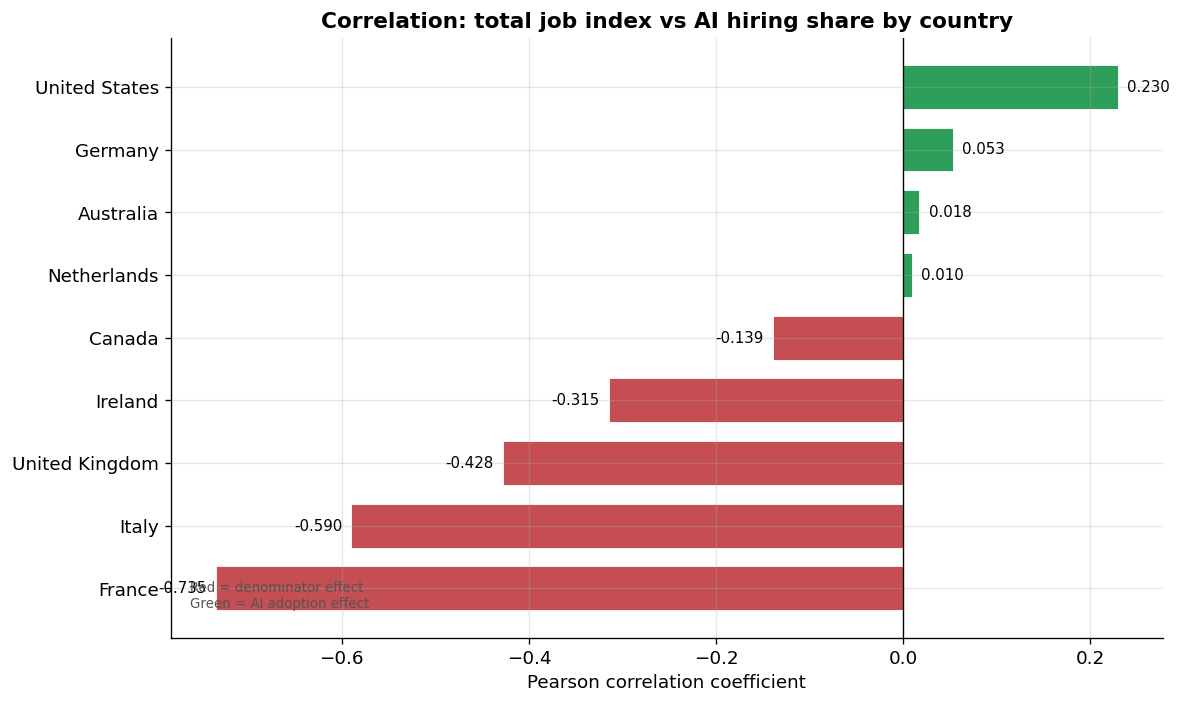

In [43]:
# visualize correlations

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#C44E52' if v < 0 else '#2E9E5B' for v in corr_df['correlation']]

bars = ax.barh(corr_df['country'], corr_df['correlation'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, corr_df['correlation']):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', ha='left' if val >= 0 else 'right', fontsize=9
    )

ax.set_title('Correlation: total job index vs AI hiring share by country',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson correlation coefficient')
ax.text(0.02, 0.05,
        'Red = denominator effect\nGreen = AI adoption effect',
        transform=ax.transAxes, fontsize=8, color='#555555')

plt.tight_layout()
plt.savefig('04_correlation_by_country.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: Correlation by country**

The results reveal two distinct patterns across markets.

**Denominator effect (negative correlation):**
France (-0.73), Italy (-0.59), United Kingdom (-0.43), 
Ireland (-0.31), and Canada (-0.14) all show negative 
correlations. In these markets, when Indeed job postings 
grew, particularly during the post-COVID boom, AI hiring 
share shrank as a percentage. General hiring grew faster 
than AI-specific requirements, diluting the AI share. 
This is strongest in France and Italy where post-COVID 
hiring recovery was robust but AI adoption in job 
postings lagged significantly.

Interestingly Ireland and Canada also fall in this group 
despite being English-speaking markets with strong tech 
sectors. Their AI hiring share is highly volatile and 
their overall job markets contracted post-ChatGPT, 
which likely drove the negative correlation over 
the full period.

**AI adoption effect (positive or near-zero):**
Netherlands (+0.01), Australia (+0.02), Germany (+0.05), 
and United States (+0.23) show AI hiring share growing 
alongside overall posting volume. AI skill requirements 
in these markets appear more broadly embedded across 
job types, not confined to specialist roles alone.

The overall picture suggests that tech sector 
concentration and how deeply AI tools have permeated 
non-tech industries are the primary drivers of adoption 
speed, more so than language or general economic 
development.

## 5. Normalized Comparison: Recovery Timing and the Great Divergence

The dual axis chart shows direction of movement but 
the two y-axes make it hard to compare magnitude 
directly. By normalizing both series to 100 at 
February 2020 we put them on the same scale and 
can directly measure how much each metric changed 
during each episode. Each era is shaded in a 
distinct color for easy reference.

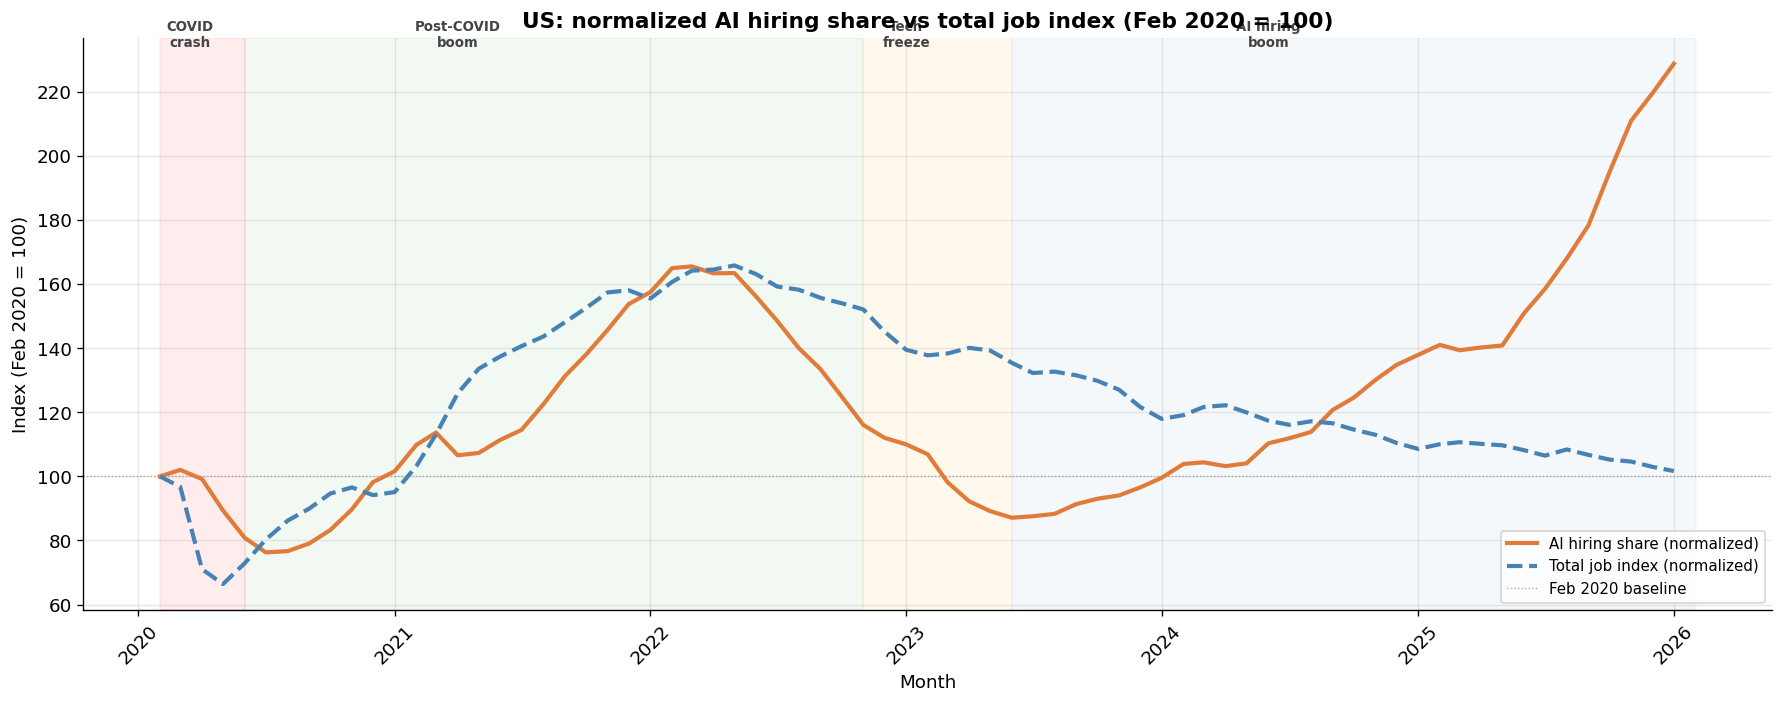

In [44]:
# normalized comparison with shaded eras — US

us = combined[combined['country'] == 'United States'].sort_values('month_dt').copy()

baseline_month = pd.Period('2020-02', freq='M')
baseline_ai    = us[us['month'] == baseline_month]['ai_share_pct'].values[0]
baseline_total = us[us['month'] == baseline_month]['job_index'].values[0]

us['ai_share_norm']  = (us['ai_share_pct'] / baseline_ai)  * 100
us['job_index_norm'] = (us['job_index']    / baseline_total) * 100

fig, ax = plt.subplots(figsize=(15, 6))

# shaded era backgrounds
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
           alpha=0.07, color='red',        zorder=0)
ax.axvspan(pd.Timestamp('2020-06-01'), pd.Timestamp('2022-11-01'),
           alpha=0.05, color='green',      zorder=0)
ax.axvspan(pd.Timestamp('2022-11-01'), pd.Timestamp('2023-06-01'),
           alpha=0.07, color='orange',     zorder=0)
ax.axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2026-02-01'),
           alpha=0.05, color='steelblue',  zorder=0)

# era labels at top of chart
ymax = max(us['ai_share_norm'].max(), us['job_index_norm'].max()) * 1.06
for label, date in ERA_LABELS:
    ax.text(date, ymax, label, fontsize=8,
            color='#444444', ha='center', va='top', fontweight='bold')

ax.plot(us['month_dt'], us['ai_share_norm'],
        color='#E07B39', linewidth=2.5,
        label='AI hiring share (normalized)', zorder=3)
ax.plot(us['month_dt'], us['job_index_norm'],
        color='steelblue', linewidth=2.5,
        linestyle='--', label='Total job index (normalized)', zorder=3)

ax.axhline(100, color='gray', linewidth=0.8,
           linestyle=':', alpha=0.7, label='Feb 2020 baseline')

ax.set_title('US: normalized AI hiring share vs total job index (Feb 2020 = 100)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Index (Feb 2020 = 100)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('05_us_normalized_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: US normalized comparison**

**COVID crash (red shading):**
Indeed job postings fell to 66.4, meaning 34% below 
the Feb 2020 baseline at the worst point. AI hiring 
share fell less severely to 80.8, holding up better 
as tech companies remained relatively resilient 
during the remote work transition.

**Post-COVID boom (green shading):**
Both lines recovered strongly and climbed in tandem. 
The job index peaked at 165.8 (66% above baseline) 
and AI hiring share peaked at 165.5 (65% above baseline) 
around the same time. Both were growing at almost 
identical rates, confirming AI hiring was simply 
riding the wave of general market growth.

**Tech hiring freeze (orange shading): the key asymmetry.**
The job index fell from its peak of 165.8 to 135.4 
by June 2023, a drop of 18%. AI hiring share collapsed 
from its peak of 165.5 to 87.1, a drop of 47%, 
nearly 3x harder than the overall market. AI and ML 
engineers were among the most expensive specialist 
hires and were cut first when cost pressures hit.

**The great divergence (blue shading):**
From mid-2023 onwards the two lines moved in completely 
opposite directions. Indeed job postings continued 
declining from 135.4 all the way to 101.6 by January 
2026, back to the Feb 2020 baseline having given back 
all post-COVID gains. AI hiring share recovered from 
its trough of 87.1 and surged to 228.8 by January 2026, 
129% above the Feb 2020 baseline. Companies are not 
posting more jobs overall but they are increasingly 
requiring AI competency from whoever they do hire.

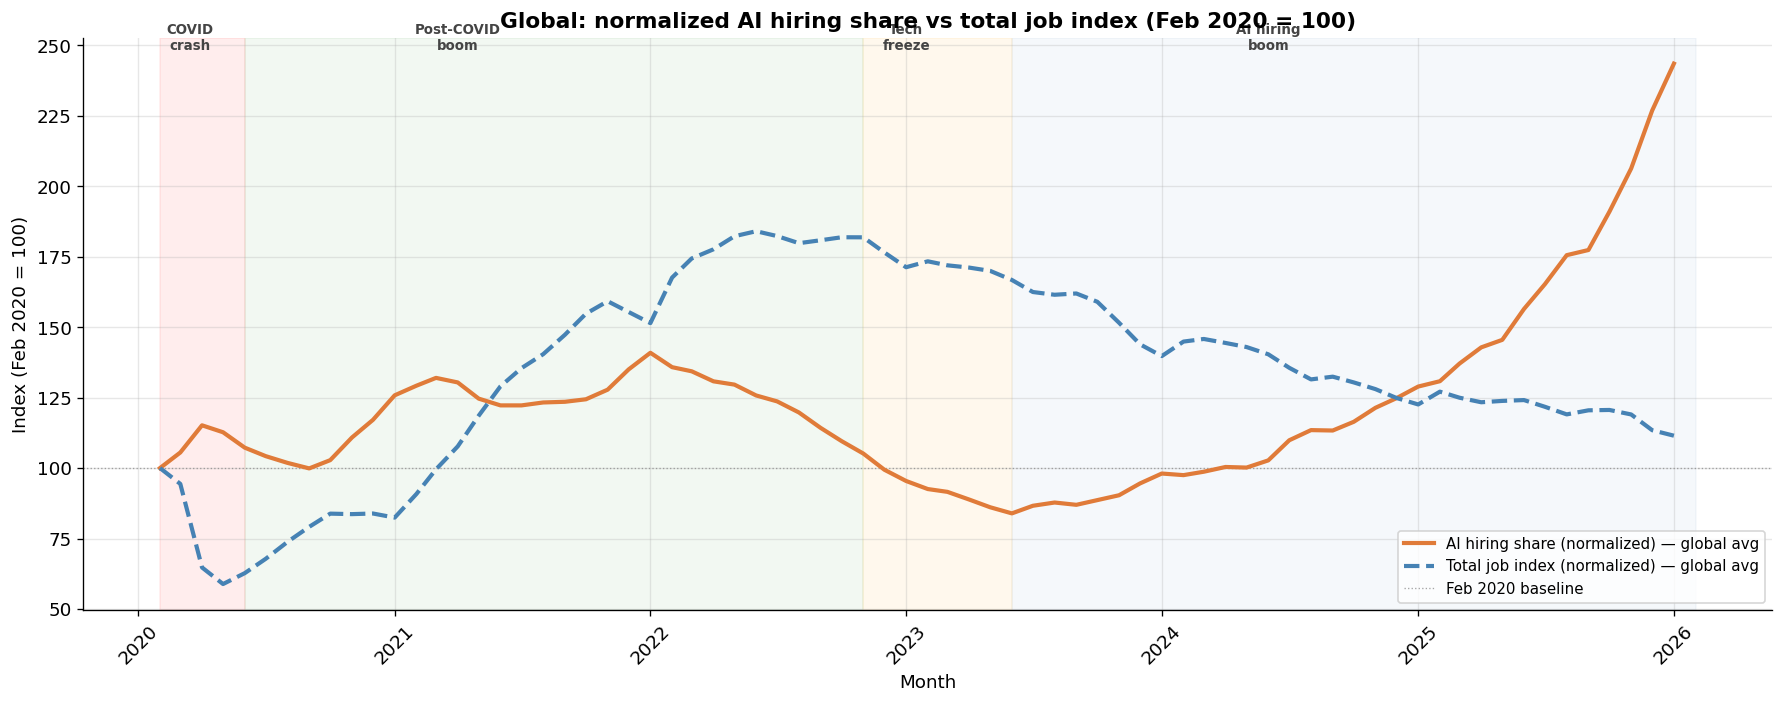

In [45]:
# normalized comparison with shaded eras — global average

baseline_month = pd.Period('2020-02', freq='M')

global_monthly = (
    combined.groupby('month_dt')
    .agg(
        ai_share_pct = ('ai_share_pct', 'mean'),
        job_index    = ('job_index',    'mean')
    )
    .reset_index()
    .sort_values('month_dt')
)
global_monthly['month'] = global_monthly['month_dt'].dt.to_period('M')

baseline_ai    = global_monthly[global_monthly['month'] == baseline_month]['ai_share_pct'].values[0]
baseline_total = global_monthly[global_monthly['month'] == baseline_month]['job_index'].values[0]

global_monthly['ai_share_norm']  = (global_monthly['ai_share_pct'] / baseline_ai)  * 100
global_monthly['job_index_norm'] = (global_monthly['job_index']    / baseline_total) * 100

fig, ax = plt.subplots(figsize=(15, 6))

ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
           alpha=0.07, color='red',       zorder=0)
ax.axvspan(pd.Timestamp('2020-06-01'), pd.Timestamp('2022-11-01'),
           alpha=0.05, color='green',     zorder=0)
ax.axvspan(pd.Timestamp('2022-11-01'), pd.Timestamp('2023-06-01'),
           alpha=0.07, color='orange',    zorder=0)
ax.axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2026-02-01'),
           alpha=0.05, color='steelblue', zorder=0)

ymax_g = max(global_monthly['ai_share_norm'].max(),
             global_monthly['job_index_norm'].max()) * 1.06
for label, date in ERA_LABELS:
    ax.text(date, ymax_g, label, fontsize=8,
            color='#444444', ha='center', va='top', fontweight='bold')

ax.plot(global_monthly['month_dt'], global_monthly['ai_share_norm'],
        color='#E07B39', linewidth=2.5,
        label='AI hiring share (normalized) — global avg', zorder=3)
ax.plot(global_monthly['month_dt'], global_monthly['job_index_norm'],
        color='steelblue', linewidth=2.5,
        linestyle='--', label='Total job index (normalized) — global avg', zorder=3)

ax.axhline(100, color='gray', linewidth=0.8,
           linestyle=':', alpha=0.7, label='Feb 2020 baseline')

ax.set_title('Global: normalized AI hiring share vs total job index (Feb 2020 = 100)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Index (Feb 2020 = 100)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('06_global_normalized.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: Global normalized**

Globally Indeed job postings held up better than 
the US after the COVID crash. Continental European 
markets did not experience the same severity of 
tech layoffs, keeping the global average above 
the US through 2022-2023.

However the global job posting index has also been 
declining since mid-2024, falling from 140.4 in 
June 2024 to 111.5 by January 2026. The direction 
mirrors the US, just less severe. Unlike the US 
which is back at its Feb 2020 baseline, the global 
average is still 11.5% above it.

Meanwhile global AI hiring share surged to 243.5 
by January 2026, even higher than the US at 228.8. 
Even as job posting volumes decline, AI requirements 
are rising across all 9 countries. The AI boom is 
not a US-only story and it is not a side effect 
of a hot job market.

## 6. Country Comparison: Pre vs Post ChatGPT

We split the data at the ChatGPT launch date and compare 
average values before and after for both metrics. The 
scatter plot tests whether the denominator effect holds 
at the country level: countries with the largest job 
posting growth post-ChatGPT should show the smallest 
AI share gains if the denominator effect is the 
primary driver.

In [46]:
# pre vs post ChatGPT averages per country

pre  = combined[combined['month_dt'] <  CHATGPT_LAUNCH]
post = combined[combined['month_dt'] >= CHATGPT_LAUNCH]

summary = pd.DataFrame({
    'ai_share_pre':    pre.groupby('country')['ai_share_pct'].mean(),
    'ai_share_post':   post.groupby('country')['ai_share_pct'].mean(),
    'job_index_pre':   pre.groupby('country')['job_index'].mean(),
    'job_index_post':  post.groupby('country')['job_index'].mean(),
})

summary['ai_share_change']  = summary['ai_share_post']  - summary['ai_share_pre']
summary['job_index_change'] = summary['job_index_post'] - summary['job_index_pre']

print('Pre vs Post ChatGPT: both metrics')
print(summary.round(2).to_string())

Pre vs Post ChatGPT: both metrics
                ai_share_pre  ai_share_post  job_index_pre  job_index_post  ai_share_change  job_index_change
country                                                                                                      
Australia               2.98           3.08         145.89          168.00             0.09             22.12
Canada                  2.64           3.50         130.31          117.61             0.86            -12.70
France                  2.15           2.08         122.85          154.19            -0.07             31.34
Germany                 2.26           2.50         124.67          140.12             0.24             15.44
Ireland                 5.38           5.91         129.52          129.69             0.54              0.17
Italy                   3.70           2.79         123.20          190.29            -0.91             67.10
Netherlands             2.35           2.08         127.03          147.73            

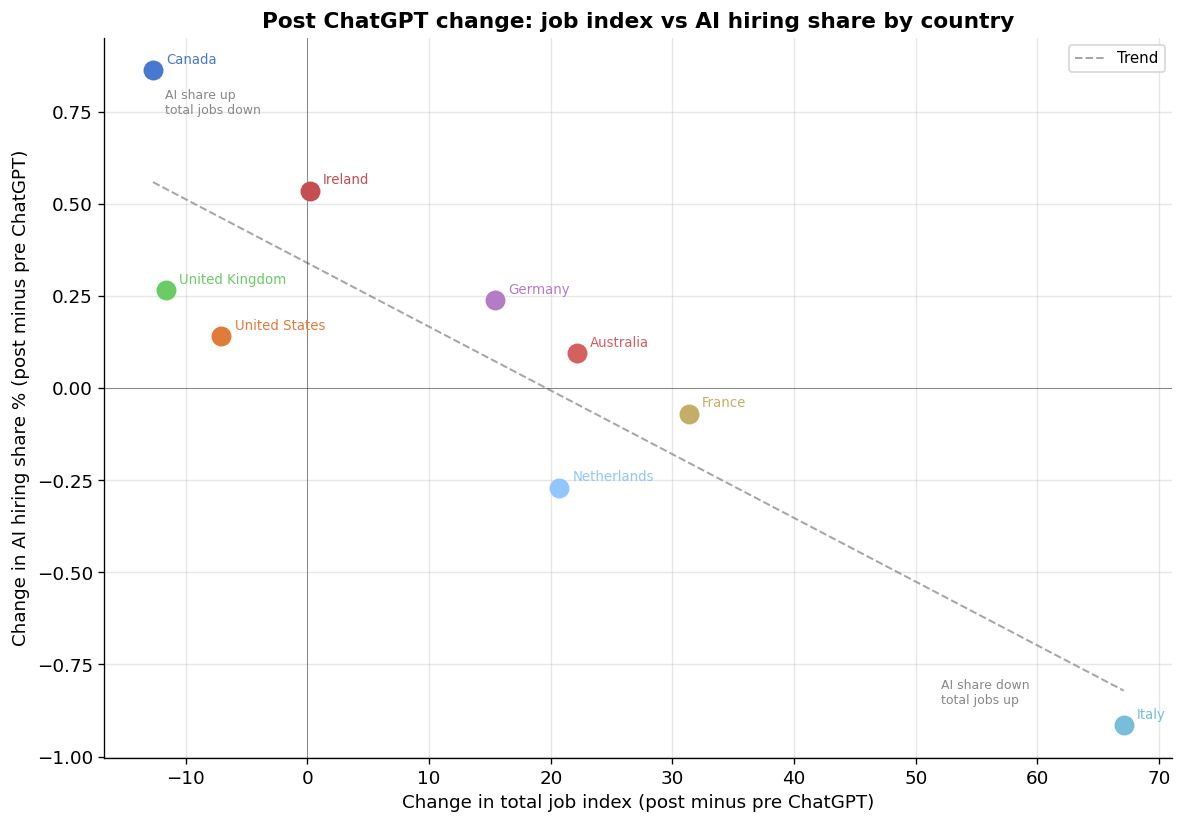

In [48]:
# scatter: job index change vs AI share change per country

fig, ax = plt.subplots(figsize=(10, 7))

for country in COUNTRIES:
    row = summary.loc[country]
    ax.scatter(row['job_index_change'], row['ai_share_change'],
               color=COUNTRY_COLORS[country], s=120, zorder=4)
    ax.annotate(
        country,
        (row['job_index_change'], row['ai_share_change']),
        textcoords='offset points', xytext=(8, 4),
        fontsize=8, color=COUNTRY_COLORS[country]
    )

x = summary['job_index_change'].values
y = summary['ai_share_change'].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color='gray',
        linewidth=1.2, linestyle='--', alpha=0.7, label='Trend')

ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
ax.axvline(0, color='black', linewidth=0.6, alpha=0.4)

# quadrant labels
ax.text(x.min() + 1, y.max() - 0.05,
        'AI share up\ntotal jobs down',
        fontsize=7.5, color='#888888', va='top')
ax.text(x.max() - 15, y.min() + 0.05,
        'AI share down\ntotal jobs up',
        fontsize=7.5, color='#888888', va='bottom')

ax.set_title('Post ChatGPT change: job index vs AI hiring share by country',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Change in total job index (post minus pre ChatGPT)')
ax.set_ylabel('Change in AI hiring share % (post minus pre ChatGPT)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('07_country_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation: Country scatter**

**Top-left quadrant (Canada, UK, US, Ireland):**
Indeed job postings contracted post-ChatGPT in these 
markets. Canada saw the sharpest drop (-12.70 index 
points), followed by the UK (-11.62) and the US (-7.09). 
Ireland barely moved (+0.17), sitting almost on the 
y-axis. Yet AI hiring share grew in all four: Canada 
+0.86, Ireland +0.54, UK +0.27, US +0.14. Companies 
required AI competency regardless of whether they were 
expanding or cutting headcount. This is the strongest 
indicator of structural change in hiring expectations.

**Top-right quadrant (Germany, Australia):**
Both job postings and AI share grew post-ChatGPT. 
Germany saw job postings grow 15.44 index points 
with AI share up 0.24, and Australia grew 22.12 
index points with AI share up 0.09. These markets 
are on a gradual adoption path where AI requirements 
are growing alongside the overall market.

**Bottom-right quadrant (Italy, Netherlands, France):**
Indeed job postings boomed post-ChatGPT. Italy grew 
67.10 index points, France 31.34, Netherlands 20.70. 
Yet AI hiring share fell in all three: Italy -0.91, 
Netherlands -0.27, France -0.07. So many non-AI jobs 
were posted that the AI percentage shrank. Italy is 
the most extreme case and the clearest example of 
the denominator effect.

The negative trend line across all 9 countries 
confirms the overall pattern: more job posting 
growth post-ChatGPT corresponded with less AI 
share growth. But the quadrants tell a more 
nuanced story. The top-left markets show AI 
becoming a structural requirement independent 
of market conditions, the top-right shows gradual 
organic adoption, and the bottom-right shows the 
denominator effect where general hiring diluted 
AI share.

## 7. Key Findings Summary

In [35]:
us_corr = combined[combined['country'] == 'United States']['job_index'].corr(
    combined[combined['country'] == 'United States']['ai_share_pct']
)

us_pre_ai   = summary.loc['United States', 'ai_share_pre']
us_post_ai  = summary.loc['United States', 'ai_share_post']
us_pre_job  = summary.loc['United States', 'job_index_pre']
us_post_job = summary.loc['United States', 'job_index_post']

print('Key findings: United States')
print(f'  Correlation (job index vs AI share): {us_corr:.3f}')
print(f'  AI share pre ChatGPT:   {us_pre_ai:.2f}%')
print(f'  AI share post ChatGPT:  {us_post_ai:.2f}%')
print(f'  Job index pre ChatGPT:  {us_pre_job:.1f}')
print(f'  Job index post ChatGPT: {us_post_job:.1f}')
print()
print('Correlation by country:')
print(corr_df.to_string(index=False))

Key findings: United States
  Correlation (job index vs AI share): 0.230
  AI share pre ChatGPT:   2.33%
  AI share post ChatGPT:  2.47%
  Job index pre ChatGPT:  127.5
  Job index post ChatGPT: 120.4

Correlation by country:
       country  correlation
        France    -0.734855
         Italy    -0.589713
United Kingdom    -0.427969
       Ireland    -0.314720
        Canada    -0.138838
   Netherlands     0.009639
     Australia     0.017553
       Germany     0.052913
 United States     0.229881


## 8. Export for Combined Reddit + Indeed Analysis

We save the daily AI share data filtered to 2025 
for use in the combined Reddit sentiment analysis. 
We focus on the US, UK, Canada, and Australia as 
these are the most active Reddit markets and our 
Reddit data is primarily English-language, making 
these the most directly comparable markets for 
a sentiment vs hiring analysis.

In [36]:
# save Indeed daily AI share for combined Reddit + Indeed analysis

ENGLISH_COUNTRIES = ['United States', 'United Kingdom', 'Canada', 'Australia']

indeed_2025 = ai_df[
    (ai_df['date'].dt.year == 2025) &
    (ai_df['country'].isin(ENGLISH_COUNTRIES))
].copy().sort_values(['country', 'date'])

indeed_2025['ai_share_7day'] = (
    indeed_2025.groupby('country')['ai_share_pct']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

english_avg = (
    indeed_2025.groupby('date')[['ai_share_pct']]
    .mean().reset_index()
)
english_avg['country'] = 'English-speaking average'
english_avg['ai_share_7day'] = english_avg['ai_share_pct'].rolling(7, min_periods=1).mean()

indeed_save = pd.concat([
    indeed_2025[['date', 'country', 'ai_share_pct', 'ai_share_7day']],
    english_avg[['date', 'country', 'ai_share_pct', 'ai_share_7day']]
], ignore_index=True)

indeed_save.to_csv('indeed_daily_2025.csv', index=False)

print(f'Saved: indeed_daily_2025.csv')
print(f'Rows: {len(indeed_save)}')
print(f'Countries: {indeed_save["country"].unique().tolist()}')
print(f'Date range: {indeed_save["date"].min()} to {indeed_save["date"].max()}')
print(indeed_save.head())

Saved: indeed_daily_2025.csv
Rows: 1825
Countries: ['Australia', 'Canada', 'United Kingdom', 'United States', 'English-speaking average']
Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
        date    country  ai_share_pct  ai_share_7day
0 2025-01-01  Australia          2.91       2.910000
1 2025-01-02  Australia          2.93       2.920000
2 2025-01-03  Australia          2.94       2.926667
3 2025-01-04  Australia          2.95       2.932500
4 2025-01-05  Australia          2.96       2.938000


## Summary of Outputs and Key Findings

| File | Contents |
|------|----------|
| `01_us_dual_axis.png` | US job index vs AI share with event annotations |
| `02_global_dual_axis.png` | Global average with event annotations |
| `03_all_countries_dual_axis.png` | All 9 countries with COVID, ChatGPT, AI boom markers |
| `04_correlation_by_country.png` | Correlation by country: denominator vs adoption effect |
| `05_us_normalized_comparison.png` | Freeze asymmetry and great divergence with shaded eras |
| `06_global_normalized.png` | Global version with shaded eras |
| `07_country_scatter.png` | Post-ChatGPT structural divide with quadrant labels |
| `indeed_daily_2025.csv` | Exported for combined Reddit + Indeed analysis |

**Four key findings:**

1. **The tech hiring freeze hit AI roles harder than 
general roles.** During 2022-2023, AI hiring share on 
Indeed fell 47% from its peak while total job postings 
fell 18%. AI-specific roles were cut disproportionately 
during the post-pandemic correction.

2. **AI hiring share decoupled from total job postings 
from 2024.** Indeed job postings in the US declined back 
to the Feb 2020 baseline by January 2026, giving back 
all post-COVID gains. AI hiring share surged to 128.8% 
above the Feb 2020 baseline over the same period. 
Companies are not posting more jobs but are increasingly 
requiring AI competency from whoever they do hire.

3. **Markets like the US, Canada, Ireland, Germany, and 
Australia lead AI adoption in hiring.** AI requirements 
grew in these markets regardless of whether overall job 
posting volumes were expanding or contracting.

4. **The denominator effect is real but geographically 
concentrated.** France, Italy, and the Netherlands saw 
general hiring boom post-ChatGPT but AI requirements 
barely moved, confirming that general hiring growth 
diluted AI share in these markets. Germany and Australia 
showed the opposite: modest hiring growth accompanied 
by modest AI share growth.